# Clasificación de textos de amazan con transformer utilizando tecnicas de fine tuning

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, EarlyStoppingCallback
from transformers import Trainer
import evaluate
from evaluate import load
import numpy as np
from torch.optim import AdamW
from datasets import load_dataset
import random
import pandas as pd
from datasets import ClassLabel
# from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

c:\Users\Jose Eduardo\Documents\GIT\clasificacion_opiniones_amazon\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

Repo card metadata block was not found. Setting CardData to empty.


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

In [4]:
control= "dccuchile/bert-base-spanish-wwm-cased"
tokenizador= AutoTokenizer.from_pretrained(control)
data_collator = DataCollatorWithPadding(tokenizer=tokenizador)
modelo= AutoModelForSequenceClassification.from_pretrained(control,num_labels=5)

for param in modelo.base_model.parameters():
    param.requires_grad = False

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 40135.91it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECT

In [5]:
def tokenizar(ejemplo):
    return tokenizador(ejemplo["text"],truncation=True)

In [6]:
columnas = dataset["train"].column_names
columnas.remove("label")
datos_tokenizados = dataset.map(tokenizar, batched=True, remove_columns=columnas)
datos_tokenizados

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})

In [7]:
recopilador_datos = DataCollatorWithPadding(tokenizer=tokenizador)

In [8]:
metrica = evaluate.load("accuracy")

In [9]:
def compute_metrics(eval_pred):
    predicciones, etiquetas = eval_pred
    predicciones = np.argmax(predicciones, axis=1)
    return metrica.compute(references=etiquetas, predictions=predicciones)

In [10]:
training_args = TrainingArguments(
    output_dir="modelo-ajustado",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    learning_rate=2e-5,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

In [11]:
trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=datos_tokenizados["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=datos_tokenizados["validation"].shuffle(seed=42).select(range(400)),
    data_collator=recopilador_datos,
    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [12]:
trainer.train()

c:\Users\Jose Eduardo\Documents\GIT\clasificacion_opiniones_amazon\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.623160,1.618440,0.222500
2,1.618674,1.613949,0.230000


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.54s/it]
c:\Users\Jose Eduardo\Documents\GIT\clasificacion_opiniones_amazon\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm

TrainOutput(global_step=500, training_loss=1.6183534393310546, metrics={'train_runtime': 363.1391, 'train_samples_per_second': 11.015, 'train_steps_per_second': 1.377, 'total_flos': 182316205401696.0, 'train_loss': 1.6183534393310546, 'epoch': 2.0})

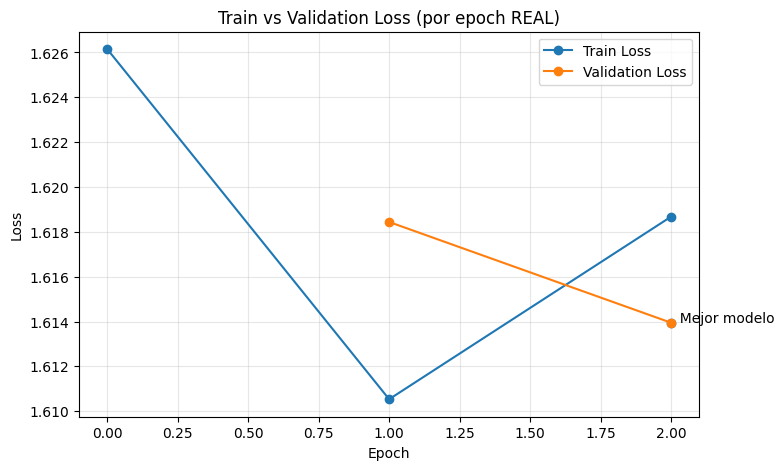

In [13]:
import matplotlib.pyplot as plt


logs = pd.DataFrame(trainer.state.log_history)

train_loss = logs[logs["loss"].notna()].copy()
train_loss["epoch_int"] = train_loss["epoch"].astype(int)
train_loss_epoch = train_loss.groupby("epoch_int")["loss"].mean()

eval_loss = logs[logs["eval_loss"].notna()].copy()
eval_loss["epoch_int"] = eval_loss["epoch"].astype(int)
eval_loss_epoch = eval_loss.groupby("epoch_int")["eval_loss"].mean()

best_epoch = eval_loss_epoch.idxmin()
best_value = eval_loss_epoch.min()

plt.figure(figsize=(8,5))

plt.plot(train_loss_epoch.index, train_loss_epoch.values, marker="o", label="Train Loss")
plt.plot(eval_loss_epoch.index, eval_loss_epoch.values, marker="o", label="Validation Loss")

plt.scatter(best_epoch, best_value)
plt.text(best_epoch, best_value, "  Mejor modelo", fontsize=10)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss (por epoch REAL)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Función de métricas (opcional si usas predict manual)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Ruta del mejor modelo
best_model_path = trainer.state.best_model_checkpoint
print("Mejor modelo en:", best_model_path)

# Cargar el mejor modelo
modelo_mejor = AutoModelForSequenceClassification.from_pretrained(best_model_path)

# Argumentos de evaluación
eval_args = TrainingArguments(
    output_dir="eval",
    per_device_eval_batch_size=8
)

# Crear Trainer (sin necesidad de eval_dataset aquí)
trainer_best = Trainer(
    model=modelo_mejor,
    args=eval_args,
    data_collator=recopilador_datos
)

# 🔥 Usar predict en lugar de evaluate
resultados_test = trainer_best.predict(datos_tokenizados["test"].shuffle(seed=42).select(range(400)))

# Obtener predicciones y etiquetas reales
preds = np.argmax(resultados_test.predictions, axis=1)
labels = resultados_test.label_ids

# Calcular métricas manualmente
precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="micro"
)

acc = accuracy_score(labels, preds)

# Mostrar resultados
print("\n=== Evaluación en TEST ===")
print(f"Accuracy:         {acc:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1-score:         {f1:.4f}")

Mejor modelo en: modelo-ajustado\checkpoint-500


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7618.70it/s]
c:\Users\Jose Eduardo\Documents\GIT\clasificacion_opiniones_amazon\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== Evaluación en TEST ===
Accuracy:         0.2425
Precision:        0.2425
Recall:           0.2425
F1-score:         0.2425
